# disscube — Tutorial Conceitual

## O que é o disscube

O **disscube** é a camada de dados do DisSModel: um sucessor reprodutível ao
`fillCellularSpace` do TerraME.

O modelo mental central é **Fonte → Derivação → Variável**:

1. **`SpatialSource`** — aponta para um arquivo (raster GeoTIFF ou vetor GeoJSON/Shapefile).
2. **`SpatialDerivation`** — especifica *qual* variável extrair, *que operador* usar e
   para *qual grade-alvo*.
3. **`DerivedVariable`** — o resultado: um array Zarr catalogado, carregado de volta
   por modelos via `to_lucc_data()`.

A derivação é **idempotente**: o mesmo `SpatialDerivation` sempre produz o mesmo
`spec_hash`; re-executar devolve o resultado em cache sem recalcular.


## Setup

In [1]:
%matplotlib inline
import pathlib, tempfile, warnings
warnings.filterwarnings("ignore")

import numpy as np
import rasterio
from rasterio.transform import from_bounds
import geopandas as gpd
from shapely.geometry import box as shapely_box
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from disscube import CubeClient, GridSpec, SpatialSource, SpatialDerivation, Variable

# Catálogo e store em tmpdir — notebook 100 % auto-contido e re-executável
tmpdir       = pathlib.Path(tempfile.mkdtemp(prefix="disscube_tutorial_"))
catalog_path = str(tmpdir / "catalog.db")
store_path   = str(tmpdir / "store")

cube = CubeClient(catalog=catalog_path, store=store_path)
print(f"Catálogo : {catalog_path}")
print(f"Store    : {store_path}")


Catálogo : /tmp/disscube_tutorial_xqefn6t2/catalog.db
Store    : /tmp/disscube_tutorial_xqefn6t2/store


## Gerar dados sintéticos

Criamos dois GeoTIFFs e uma camada vetorial diretamente em memória e os salvamos
num `tmpdir`.  Nenhum arquivo externo é lido.

* **Uso da terra**: raster categórico com 3 classes (1 = floresta, 2 = pastagem,
  3 = agricultura) a 50 m de resolução.
* **Elevação**: raster contínuo com gradiente N-S (500 → 100 m) a 50 m.
* **APAs**: duas áreas de proteção ambiental como polígonos vetoriais.

A grade-fonte tem **100 × 100 pixels a 50 m** numa janela de 5 × 5 km em
EPSG:31982 (SIRGAS 2000 / UTM zona 22S).


In [2]:
# ── Parâmetros espaciais ──────────────────────────────────────────────────────
CRS_STR   = "EPSG:31982"                          # SIRGAS 2000 / UTM 22S (metros)
BBOX      = [600000.0, 7200000.0, 605000.0, 7205000.0]  # [minx, miny, maxx, maxy]
FINE_RES  = 50.0
FINE_COLS = int((BBOX[2] - BBOX[0]) / FINE_RES)  # 100
FINE_ROWS = int((BBOX[3] - BBOX[1]) / FINE_RES)  # 100
transform = from_bounds(BBOX[0], BBOX[1], BBOX[2], BBOX[3], FINE_COLS, FINE_ROWS)

print(f"Grade-fonte: {FINE_ROWS} × {FINE_COLS} pixels @ {FINE_RES:.0f} m")

# ── Raster categórico: uso da terra ──────────────────────────────────────────
# Padrão espacial simples: três zonas horizontais/verticais
lu_array = np.ones((FINE_ROWS, FINE_COLS), dtype=np.int16)
lu_array[:, 50:]  = 2   # metade direita  → pastagem
lu_array[70:, :]  = 3   # 30 % inferior   → agricultura

# ── Raster contínuo: elevação ────────────────────────────────────────────────
# Gradiente norte (row 0) = 500 m  →  sul (row 99) = 100 m
elev_array = (
    np.linspace(500, 100, FINE_ROWS).reshape(-1, 1)
    * np.ones((1, FINE_COLS))
).astype(np.float32)

# ── Salvar GeoTIFFs ───────────────────────────────────────────────────────────
lu_path   = str(tmpdir / "uso_terra.tif")
elev_path = str(tmpdir / "elevacao.tif")

for path, data, dtype in [
    (lu_path,   lu_array,   "int16"),
    (elev_path, elev_array, "float32"),
]:
    with rasterio.open(
        path, "w", driver="GTiff",
        width=FINE_COLS, height=FINE_ROWS, count=1,
        dtype=dtype, crs=CRS_STR, transform=transform,
    ) as dst:
        dst.write(data, 1)

print(f"  uso_terra.tif → shape {lu_array.shape}, dtype {lu_array.dtype}")
print(f"  elevacao.tif  → shape {elev_array.shape}, dtype {elev_array.dtype}")

# ── Camada vetorial: áreas de proteção ambiental (APA) ───────────────────────
apa_gdf = gpd.GeoDataFrame(
    {"id": [1, 2], "nome": ["APA Norte", "APA Sul"]},
    geometry=[
        shapely_box(601000, 7202500, 602500, 7204500),
        shapely_box(603000, 7200500, 604500, 7202000),
    ],
    crs=CRS_STR,
)
apa_path = str(tmpdir / "apa.geojson")
apa_gdf.to_file(apa_path, driver="GeoJSON")
print(f"  apa.geojson   → {len(apa_gdf)} feições")


Grade-fonte: 100 × 100 pixels @ 50 m


  uso_terra.tif → shape (100, 100), dtype int16
  elevacao.tif  → shape (100, 100), dtype float32


  apa.geojson   → 2 feições


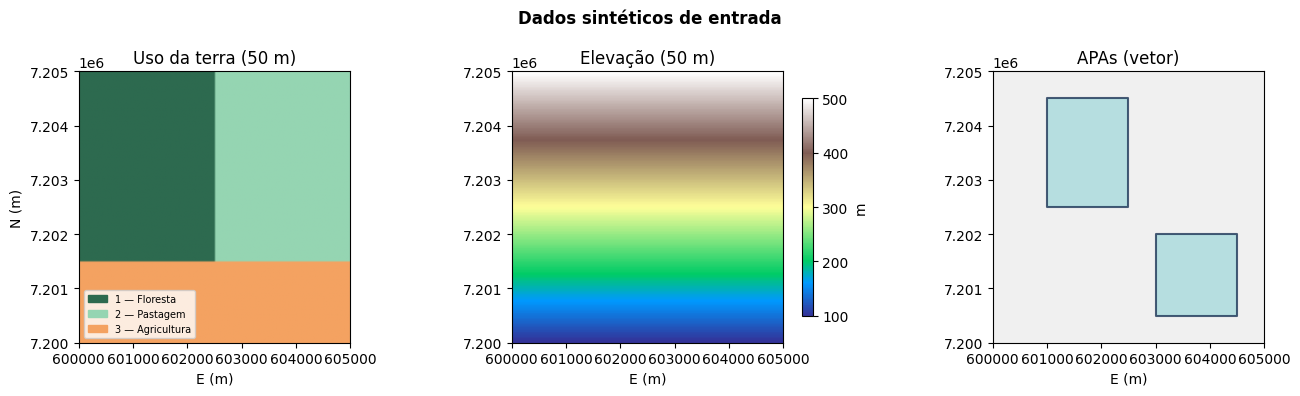

In [3]:
# ── Visualizar dados de entrada ───────────────────────────────────────────────
extent_m = [BBOX[0], BBOX[2], BBOX[1], BBOX[3]]   # [xmin, xmax, ymin, ymax] p/ imshow
cmap_lu  = mcolors.ListedColormap(["#2d6a4f", "#95d5b2", "#f4a261"])
lu_legend = [
    Patch(color="#2d6a4f", label="1 — Floresta"),
    Patch(color="#95d5b2", label="2 — Pastagem"),
    Patch(color="#f4a261", label="3 — Agricultura"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.imshow(lu_array, extent=extent_m, cmap=cmap_lu, vmin=1, vmax=3, origin="upper")
ax.set_title("Uso da terra (50 m)")
ax.set_xlabel("E (m)"); ax.set_ylabel("N (m)")
ax.legend(handles=lu_legend, fontsize=7, loc="lower left")

ax = axes[1]
im = ax.imshow(elev_array, extent=extent_m, cmap="terrain", origin="upper")
ax.set_title("Elevação (50 m)")
ax.set_xlabel("E (m)")
plt.colorbar(im, ax=ax, label="m", shrink=0.8)

ax = axes[2]
ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
ax.set_facecolor("#f0f0f0")
apa_gdf.plot(ax=ax, color="#a8dadc", edgecolor="#1d3557", linewidth=1.5, alpha=0.8)
ax.set_title("APAs (vetor)")
ax.set_xlabel("E (m)")

plt.suptitle("Dados sintéticos de entrada", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Registrar a grade-alvo (`GridSpec`)

A `GridSpec` define **onde** as células do cubo estão no espaço.

Campos obrigatórios:
| Campo | Tipo | Descrição |
|-------|------|-----------|
| `id` | `str` | Identificador único (ex: `"municipio/500m"`) |
| `type` | `"local"` / `"global"` / `"reference"` | Escopo da grade |
| `crs` | `str` | Sistema de referência (string EPSG ou Proj4) |
| `resolution` | `float` | Tamanho do pixel em unidades do CRS |
| `bbox` | `[minx, miny, maxx, maxy]` | Extensão espacial |

Usamos 500 m para a grade-alvo — **10× mais grosseiro** que a fonte (50 m).
Cada célula-alvo cobre 10 × 10 = 100 pixels-fonte.


In [4]:
TARGET_RES = 500.0   # resolução do cubo (10× a fonte)

grid = GridSpec(
    id          = "estudo/500m",
    type        = "local",
    crs         = CRS_STR,
    resolution  = TARGET_RES,
    bbox        = BBOX,
    description = "Grade de estudo — 500 m pixels, SIRGAS/UTM 22S",
)
cube.register_grid(grid)

print(f"Grade registrada : {grid.id}")
print(f"  CRS            : {grid.crs}")
print(f"  Resolução      : {grid.resolution:.0f} m")
print(f"  Dimensões      : {grid.rows} linhas × {grid.cols} colunas")
print(f"  Fator fine→alvo: {int(TARGET_RES / FINE_RES)}:1  "
      f"({int(TARGET_RES / FINE_RES)**2} pixels-fonte por célula-alvo)")


Grade registrada : estudo/500m
  CRS            : EPSG:31982
  Resolução      : 500 m
  Dimensões      : 10 linhas × 10 colunas
  Fator fine→alvo: 10:1  (100 pixels-fonte por célula-alvo)


## Registrar fontes (`SpatialSource`)

`SpatialSource` descreve **onde o dado bruto está** e em que formato.

Campos principais:
| Campo | Descrição |
|-------|-----------|
| `id` | Identificador único da fonte |
| `format` | `"raster"` ou `"vector"` |
| `asset_url` | Caminho local ou URL do arquivo |
| `crs` | CRS declarado (autoridade sobre o CRS do arquivo) |
| `band_map` | `{nome_variável: índice_banda}` — quando o raster tem múltiplas bandas |
| `bbox` | Extensão da fonte (opcional, informativo) |

A fonte é registrada no catálogo uma vez; as derivações podem reutilizá-la
com operadores diferentes ou em grades diferentes sem copiar os dados.


In [5]:
src_lu = SpatialSource(
    id        = "src_uso_terra",
    name      = "Uso da terra sintético",
    format    = "raster",
    asset_url = lu_path,
    crs       = CRS_STR,
    bbox      = BBOX,
)
cube.register_spatial_source(src_lu)

src_elev = SpatialSource(
    id        = "src_elevacao",
    name      = "Elevação sintética",
    format    = "raster",
    asset_url = elev_path,
    crs       = CRS_STR,
    bbox      = BBOX,
)
cube.register_spatial_source(src_elev)

src_apa = SpatialSource(
    id        = "src_apa",
    name      = "Áreas de proteção ambiental",
    format    = "vector",
    asset_url = apa_path,
    crs       = CRS_STR,
)
cube.register_spatial_source(src_apa)

print("Fontes registradas:")
for src in [src_lu, src_elev, src_apa]:
    fname = pathlib.Path(src.asset_url).name
    print(f"  [{src.format:6s}] {src.id!r:20s}  →  {fname}")


Fontes registradas:
  [raster] 'src_uso_terra'       →  uso_terra.tif
  [raster] 'src_elevacao'        →  elevacao.tif
  [vector] 'src_apa'             →  apa.geojson


## Derivar variáveis (`SpatialDerivation` + operadores)

`SpatialDerivation` é o coração do pipeline: une uma fonte, uma grade-alvo e
uma lista de `Variable` (nome + operador).

### Operadores disponíveis

| Operador | Tipo de fonte | O que faz | Equivalente TerraME |
|----------|--------------|-----------|---------------------|
| `majority` | raster/vetor | Classe dominante por célula | `fillCellularSpace(…, "majority")` |
| `percentage` | raster/vetor | Fração de uma classe (0–1) — requer `class_code` | `fillCellularSpace(…, "area")` |
| `mean` | raster | Média dos pixels-fonte | `fillCellularSpace(…, "average")` |
| `min_distance` | vetor | Distância euclidiana à feição mais próxima (m) | `fillCellularSpace(…, "minimum")` |
| `presence` | vetor | Máscara binária (0/1) | — |
| `count` | vetor | Contagem de feições por célula | — |
| `min` / `max` / `sum` / `std` | raster | Estatísticas contínuas | — |

Operadores categóricos (`majority`, `percentage`, `minority`) usam **alinhamento
fino**: o pipeline lê os pixels-fonte em resolução original e agrega por janela,
preservando a composição de classes — nunca interpola um código de classe.


In [6]:
# ── 1. Classe dominante de uso da terra (majority) ────────────────────────────
derived_uso = cube.derive(SpatialDerivation(
    source_id = "src_uso_terra",
    grid_id   = "estudo/500m",
    role      = "driver",
    variables = [Variable(name="uso_dominante", operator="majority")],
))
print(f"[majority ]  {[v.name for v in derived_uso]}")

# ── 2. Proporção de floresta — classe 1 (percentage) ─────────────────────────
derived_pct = cube.derive(SpatialDerivation(
    source_id = "src_uso_terra",
    grid_id   = "estudo/500m",
    role      = "driver",
    variables = [Variable(name="prop_floresta", operator="percentage", class_code=1)],
))
print(f"[percentage]  {[v.name for v in derived_pct]}")

# ── 3. Elevação média por célula (mean) ───────────────────────────────────────
derived_elev = cube.derive(SpatialDerivation(
    source_id = "src_elevacao",
    grid_id   = "estudo/500m",
    role      = "driver",
    variables = [Variable(name="elevacao_media", operator="mean")],
))
print(f"[mean      ]  {[v.name for v in derived_elev]}")

# ── 4. Distância mínima às APAs (min_distance, fonte vetorial) ───────────────
derived_apa = cube.derive(SpatialDerivation(
    source_id = "src_apa",
    grid_id   = "estudo/500m",
    role      = "driver",
    variables = [Variable(name="dist_apa", operator="min_distance")],
))
print(f"[min_dist  ]  {[v.name for v in derived_apa]}")


[majority ]  ['uso_dominante']
[percentage]  ['prop_floresta']


[mean      ]  ['elevacao_media']


[min_dist  ]  ['dist_apa']


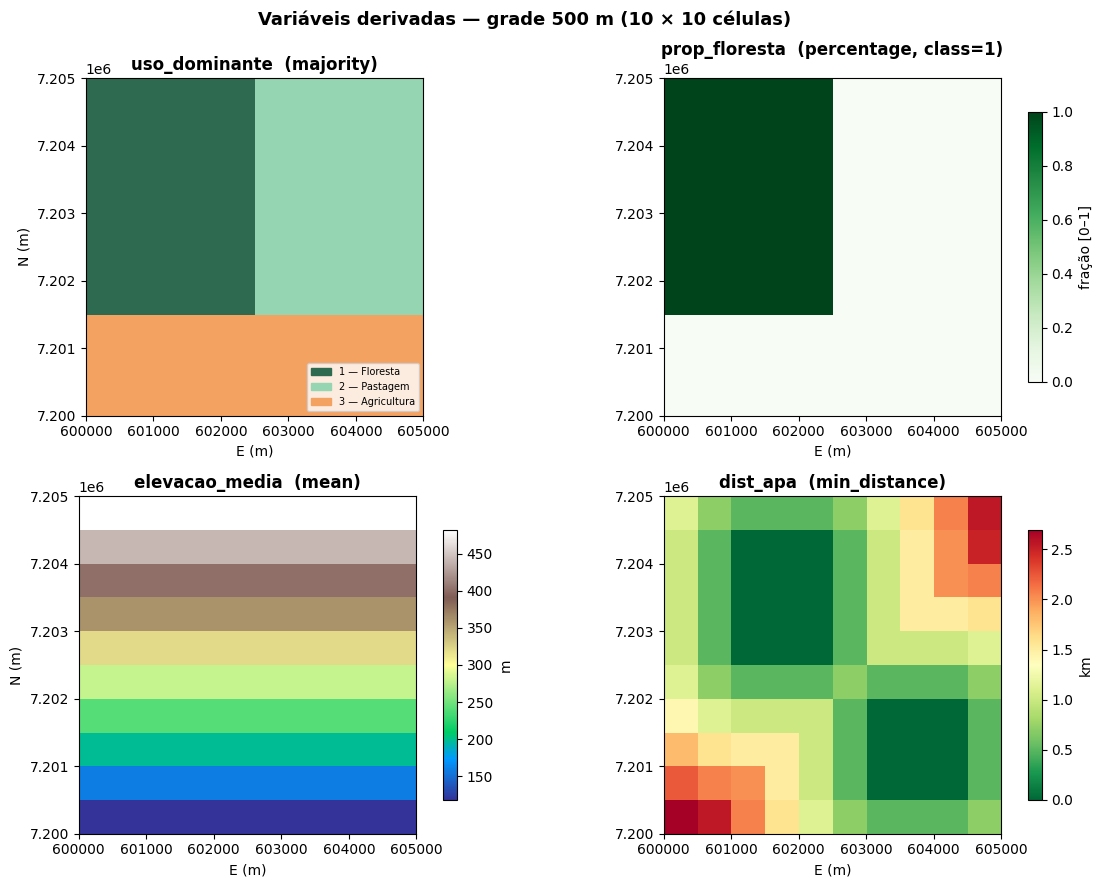

Shape das células: (10, 10)  (= 10 linhas × 10 colunas)


In [7]:
# ── Carregar e plotar os resultados ───────────────────────────────────────────
da_uso  = cube.load("uso_dominante",  grid_id="estudo/500m")
da_pct  = cube.load("prop_floresta",  grid_id="estudo/500m")
da_elev = cube.load("elevacao_media", grid_id="estudo/500m")
da_dist = cube.load("dist_apa",       grid_id="estudo/500m")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.imshow(da_uso.values, cmap=cmap_lu, vmin=1, vmax=3,
          origin="upper", extent=extent_m)
ax.set_title("uso_dominante  (majority)", fontweight="bold")
ax.legend(handles=lu_legend, fontsize=7, loc="lower right")
ax.set_xlabel("E (m)"); ax.set_ylabel("N (m)")

ax = axes[0, 1]
im = ax.imshow(da_pct.values, cmap="Greens", vmin=0, vmax=1,
               origin="upper", extent=extent_m)
ax.set_title("prop_floresta  (percentage, class=1)", fontweight="bold")
plt.colorbar(im, ax=ax, label="fração [0–1]", shrink=0.8)
ax.set_xlabel("E (m)")

ax = axes[1, 0]
im = ax.imshow(da_elev.values, cmap="terrain", origin="upper", extent=extent_m)
ax.set_title("elevacao_media  (mean)", fontweight="bold")
plt.colorbar(im, ax=ax, label="m", shrink=0.8)
ax.set_xlabel("E (m)"); ax.set_ylabel("N (m)")

ax = axes[1, 1]
im = ax.imshow(da_dist.values / 1000, cmap="RdYlGn_r",
               origin="upper", extent=extent_m)
ax.set_title("dist_apa  (min_distance)", fontweight="bold")
plt.colorbar(im, ax=ax, label="km", shrink=0.8)
ax.set_xlabel("E (m)")

plt.suptitle(f"Variáveis derivadas — grade {TARGET_RES:.0f} m "
             f"({grid.rows} × {grid.cols} células)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Shape das células: {da_uso.shape}  (= {grid.rows} linhas × {grid.cols} colunas)")


### Coordenadas de pureza (`coverage_purity` / `dominance_purity`)

Operadores categóricos anexam duas **coordenadas auxiliares** ao DataArray:

| Coordenada | Significado |
|------------|-------------|
| `coverage_purity` | fração de pixels *válidos* (sem nodata) na célula-alvo |
| `dominance_purity` | fração ocupada pela classe dominante dentre os pixels válidos |

`coverage_purity = 1.0` significa que todos os pixels-fonte da célula foram válidos.
`dominance_purity = 1.0` significa que a célula é 100 % homogênea (uma única classe).
Valores baixos de dominância indicam células mistas — úteis para mascaramento ou
análise de incerteza em modelos de mudança.


In [8]:
print("Coordenadas de 'uso_dominante':", list(da_uso.coords))
print()
print("coverage_purity (todos deveriam ser 1.0 — sem nodata nos dados sintéticos):")
print(da_uso.coords["coverage_purity"].values)
print()
print("dominance_purity (fração da classe dominante por célula):")
print(da_uso.coords["dominance_purity"].values.round(3))


Coordenadas de 'uso_dominante': ['y', 'coverage_purity', 'x', 'dominance_purity']

coverage_purity (todos deveriam ser 1.0 — sem nodata nos dados sintéticos):
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

dominance_purity (fração da classe dominante por célula):
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


## O catálogo

O catálogo SQLite registra cada `DerivedVariable` produzida.
`cube.search()` permite inspecionar o que já foi derivado por grade ou papel.

O campo **`spec_hash`** é um SHA-256 determinístico da especificação completa
(`source_id`, `grid_id`, `role`, `variables`, `valid_from`, `valid_until`).
Duas derivações com a mesma especificação terão o mesmo hash e serão tratadas
como idênticas — o pipeline *não* recalcula, apenas devolve o cache.


In [9]:
all_vars = cube.search(grid="estudo/500m")
print(f"Variáveis catalogadas para 'estudo/500m': {len(all_vars)}\n")
print(f"{'Nome':<20}  {'Role':<10}  {'dtype':<10}  spec_hash (8 chars)")
print("-" * 60)
for v in all_vars:
    print(f"{v.name:<20}  {v.role:<10}  {v.dtype:<10}  {v.spec_hash[:8]}")


Variáveis catalogadas para 'estudo/500m': 4

Nome                  Role        dtype       spec_hash (8 chars)
------------------------------------------------------------
uso_dominante         driver      float64     753a28bb
prop_floresta         driver      float64     1e3071af
elevacao_media        driver      float32     d53e2b79
dist_apa              driver      float64     2f0b0bca


In [10]:
# Re-derivar com a mesma especificação → hash idêntico, sem recálculo
derived_uso_2 = cube.derive(SpatialDerivation(
    source_id = "src_uso_terra",
    grid_id   = "estudo/500m",
    role      = "driver",
    variables = [Variable(name="uso_dominante", operator="majority")],
))
print("Hashes idênticos?", derived_uso[0].spec_hash == derived_uso_2[0].spec_hash)
print(f"  1ª derivação : {derived_uso[0].spec_hash[:16]}…")
print(f"  2ª derivação : {derived_uso_2[0].spec_hash[:16]}…")


Hashes idênticos? True
  1ª derivação : 753a28bb12c6988d…
  2ª derivação : 753a28bb12c6988d…


## Carregar e consumir (`to_lucc_data`)

`cube.load(name, grid_id=…)` carrega uma única variável como `xr.DataArray`.

`cube.to_lucc_data(names, grid_id=…)` carrega várias variáveis de uma vez e
retorna um `RasterBackend` — a **interface contratual** entre o cubo de dados
e os modelos DisSModel.

O `RasterBackend` é agnóstico a domínio: expõe arrays NumPy nomeados e operações
vetorizadas (vizinhança, deslocamento, máscara de nodata).  Modelos de CA
chamam `backend.get("nome")` a cada passo — sem saber como a variável foi derivada.

> **Nota**: `to_lucc_data` depende do pacote `dissmodel` (repositório irmão).
> Em instalações sem o DisSModel, use `cube.load()` diretamente para acessar
> os arrays como `xr.DataArray`.


In [11]:
backend = cube.to_lucc_data(
    ["uso_dominante", "prop_floresta", "elevacao_media", "dist_apa"],
    grid_id="estudo/500m",
)

print("RasterBackend carregado com sucesso!")
print(f"  Shape       : {backend.shape}  (linhas × colunas)")
print(f"  Variáveis   : {list(backend.arrays.keys())}")
print()

# Acessar variáveis via backend.get()
for name in backend.arrays:
    arr = backend.get(name)
    print(f"  {name:<20}  shape={arr.shape}  "
          f"min={np.nanmin(arr):.2f}  max={np.nanmax(arr):.2f}")


RasterBackend carregado com sucesso!
  Shape       : (10, 10)  (linhas × colunas)
  Variáveis   : ['uso_dominante', 'prop_floresta', 'elevacao_media', 'dist_apa']

  uso_dominante         shape=(10, 10)  min=1.00  max=3.00
  prop_floresta         shape=(10, 10)  min=0.00  max=1.00
  elevacao_media        shape=(10, 10)  min=118.18  max=481.82
  dist_apa              shape=(10, 10)  min=0.00  max=2692.58


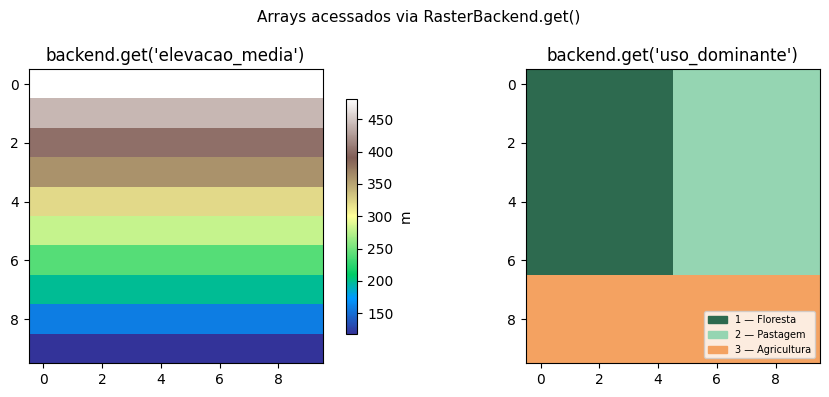


Este é o contrato que um modelo CA usa para ler o cubo.
O modelo chama backend.get('nome') a cada passo — sem conhecer a origem dos dados.


In [12]:
# Demonstrar backend.get() — interface que um modelo CA usa
elev_arr = backend.get("elevacao_media")
uso_arr  = backend.get("uso_dominante")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(elev_arr, cmap="terrain", origin="upper")
axes[0].set_title("backend.get('elevacao_media')")
plt.colorbar(im, ax=axes[0], label="m", shrink=0.8)

axes[1].imshow(uso_arr, cmap=cmap_lu, vmin=1, vmax=3, origin="upper")
axes[1].set_title("backend.get('uso_dominante')")
axes[1].legend(handles=lu_legend, fontsize=7, loc="lower right")

plt.suptitle("Arrays acessados via RasterBackend.get()", fontsize=11)
plt.tight_layout()
plt.show()

print("\nEste é o contrato que um modelo CA usa para ler o cubo.")
print("O modelo chama backend.get('nome') a cada passo — sem conhecer a origem dos dados.")


## Resumo

O fluxo completo do disscube em cinco etapas:

```
1. CubeClient(catalog, store)          # aponta para catálogo + armazenamento
2. register_grid(GridSpec)             # define ONDE as células estão
3. register_spatial_source(SpatialSource)  # define DE ONDE vem o dado bruto
4. derive(SpatialDerivation)           # transforma fine → coarse via operador
5. to_lucc_data([nomes], grid_id)      # entrega RasterBackend ao modelo
```

### Para continuar

* **Estudos de caso reais**: `examples/case_studies/maranhao/` e
  `examples/case_studies/lucc_acre/` — derivações sobre MapBiomas, MDE e
  camadas vetoriais do Brazil Data Cube.
* **Derivação declarativa**: `Derivation` (em `disscube.derivation`) é uma
  interface mais concisa que `SpatialDerivation` — valida o operador em tempo
  de construção e produz o mesmo hash.
* **Variáveis temporais**: passe `valid_from` e `valid_until` na derivação
  para criar séries anuais (MapBiomas 2000–2023, por exemplo); `to_lucc_data`
  com `period=(início, fim)` filtra a janela temporal e o `RasterBackend`
  expõe `backend.get(nome, time=ano)`.
